# Homework sheet 2 by Hazel Remmen, 5751152.
We start with some definitions, and functions we defined in the not-to-be-handed-in part of the homework. Then we get to the handin section.

In [204]:
using LinearAlgebra
using CairoMakie # For barplot. 
# using SparseArrays
# using BenchmarkTools 
using Gadfly
using Plots

# Pre-assignments: construction of p_e, A and f. 

In [205]:

function get_p_e(xs)
    # Using a list of x, construct p matrix
    # We could do this from h directly, but only for uniformly distributed x's
    p=zeros(length(xs)-1, 2)
    e=zeros(Int64, length(xs)-1, 2)

    for i in 1:(length(xs)-1)
        p[i, 1] = xs[i]
        p[i, 2] = xs[i+1]

        e[i, 1] = i
        e[i, 2] = i+1
    end

    return p, e
end

function f_source(x)
    f((x)) = sin(3.1415 * x);

    return f(x)
end

function get_A_matrix(p_e, i)
    p = p_e[1]
    
    A=Tridiagonal([-1.], [1.,1.],[-1.])
    x_i0=p[i,1]
    x_i1=p[i,2]

    if x_i1-x_i0==0 
        error("Division by zero in get_A_matrix")
    end
    
    frac = 1 / (x_i1-x_i0)
    return frac*A
end

function get_f_matrix(p_e, i)
    p = p_e[1]

    x_i0=p[i,1]
    x_i1=p[i,2]

    frac = (x_i1-x_i0)/2
    f = [f_source(x_i0),f_source(x_i1)]
    return frac*f
end

function get_global_A_matrix(p_e)
    e = p_e[2]

    # n describes number of intervals!!
    n = length(e[:,1])
    A=zeros(n+1, n+1)

    for i in 1:n
        A_e_i=get_A_matrix(p_e, i)

        for j in 1:2

            for k in 1:2
                A[e[i,j],e[i,k]]=A[e[i,j],e[i,k]]+A_e_i[j,k]
            end
        end
    end

    # Boundary conditions...
    A[1,1]=1
    A[1,2]=0

    A[end,:].=0
    A[end,end]=1

    return A
end

function get_global_f_matrix(p_e)
    e = p_e[2]

    n = length(e[:,1])
    f = zeros(n+1, 1)
    for i in 1:n
        f_e_i=get_f_matrix(p_e, i)

        for j in 1:2
            f[e[i,j]]=f[e[i,j]]+f_e_i[j]
        end
    end
    
    # BC's
    f[1]=0
    f[end]=0

    return f
end


# Nodes. There are n elements between nodes, so length(xs)=n+1
xs=[0.0, 1/4, 2/4, 3/4, 1.0]
p_e=get_p_e(xs);

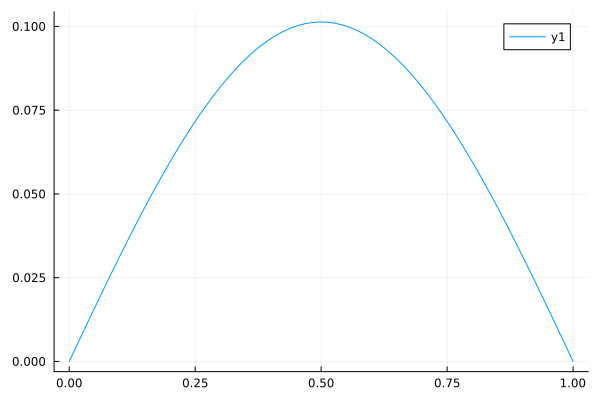

In [206]:
n = 100
xs = range(0, 1, n+1)
p_e=get_p_e(xs)

A = get_global_A_matrix(p_e)

f = get_global_f_matrix(p_e)

u = A\f
Plots.plot(xs, u)


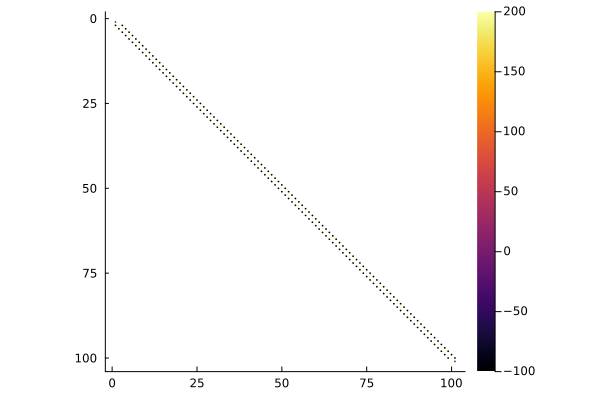

In [207]:
Plots.spy(A)



# The hand-in assignments start here!
# Assignment 1: Create $f^h$

In [208]:
h=1/3
n=convert(Int, 1/h)
xs = range(0, 1, n+1)
p_e = get_p_e(xs)

get_global_f_matrix(p_e)

4×1 Matrix{Float64}:
 0.0
 0.2886699870354815
 0.2886854288874088
 0.0

We can see this vector has 1/h+1 = 4 elements, which we expect as h=1/3 means there are 4 simulation nodes: 0, 1/3, 2/3, 1. Each needs a representation within f. The first and last values are zero, which represent the boundary conditions.

# Assignment 2: Compare FEM/FDM to compute $f^h$

We need the FDM method to also acquire f. I will also include the construction of A, as it will come in handy later. I won't explain the construction of FDM, as that was last homework sheets' difficulty.
I provide three plots: The FDM's $f$, the FEM's $f$ and their difference.

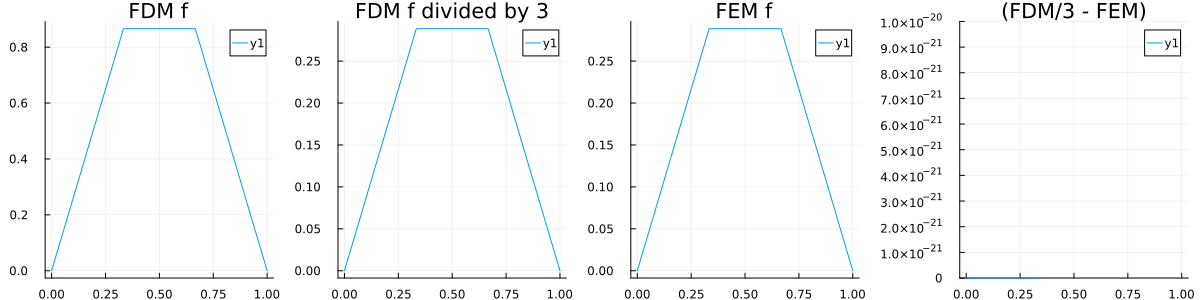

In [209]:
function get_A_FDM(h)
    Np1 = convert(Int, 1/h+1)

    ID = Diagonal(repeat([1],Np1))
    # 2nd difference
    A = Tridiagonal(repeat([-1], Np1-1), repeat([2], Np1), repeat([-1], Np1-1)) #lower, middle, upper)

    # Dirichlet BC
    A[1,:] .= 0
    A[1,1] = 1

    # Neumann BC
    A[end,:] .= 0
    A[end,end]   = 1

    # No need for Kron, we are just doing 1D solution.
    return ( 1 / (h*h) ) * A
end

function get_f_FDM(h)
    xs = range(0, 1, step=h)
    fs = f_source.(xs)
    # BC's
    fs[1] = 0
    fs[end] = 0

    return fs
end

# First plot: FDM solution
h=1/3
f_fdm = get_f_FDM(h)
p1 = Plots.plot(xs, f_fdm, title="FDM f")

p2 = Plots.plot(xs, f_fdm/3, title="FDM f divided by 3")

# Second plot: FEM solution
n = convert(Int64, 1/h)
xs = range(0, 1, n+1)
p_e = get_p_e(xs)
f_fem = get_global_f_matrix(p_e)
p3 = Plots.plot(xs, f_fem, title="FEM f")

# Third plot: Difference
p4 = Plots.plot(xs, f_fdm/3 - f_fem,
    title="(FDM/3 - FEM)",
    ylims=(0, 1e-20),
    yticks=0:1e-21:1e-20
)

# Combine plots side-by-side
Plots.plot(p1, p2, p3, p4, layout=(1, 4), size=(1200, 300))

What do we see?
We can see that the FDM and FEM solutions are very similar in shape. 

When we in fact multiply the FDM $f$ by 1/3, and compare it with the FEM $f$, we see that their difference is smaller than $10^{-21}$. This is enough evidence for me to suggest they are exactly equal, under this multiplication. The extra division by h=1/3 appears from the difference by which FEM and FDM construct their vector f. 

# Assignment 3: Give the output of the code that constructs A^h
We've already written the code up above, we just need to explain that it indeed works.

In [210]:
n=3
h=1/n
xs = range(0, 1, step=h)
p_e = get_p_e(xs)
Ah = get_global_A_matrix(p_e)
display(Ah)

4×4 Matrix{Float64}:
  1.0   0.0   0.0   0.0
 -3.0   6.0  -3.0   0.0
  0.0  -3.0   6.0  -3.0
  0.0   0.0   0.0   1.0

We can see two things clearly happening in the matrix. Firstly, the submatrix (I like to call it a "template" or "stamp", as the global matrix is built up by stamping the smaller one in clever places):
$$\cfrac{1}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}$$
can be clearly seen along the diagonal, as 1/h=3. The 6's appear from the overlap of the top-left 1 from one stamp, and the bottom-left 1 from another stamp being added up. 
On the top and bottom rows, we can see the initial condition being handled correctly, as we want a homogeneous dirichlet condition. The all-zero row except for the first or last element fullfills this condition, as desired.

# Assignment 4: Compare FEM $Ah$ and FDM $Ah$
We first get the FDM Ah here using the function we described above. Hopefully the syntax speaks for itself here.

In [211]:
# FDM
h=1/3
A_FDM=get_A_FDM(h)
println("FDM Matrix")
display(A_FDM)

# FEM
xs = range(0, 1, step=h)
p_e = get_p_e(xs)
A_FEM = get_global_A_matrix(p_e)
println("FEM Matrix")
display(A_FEM)


FDM Matrix


4×4 Tridiagonal{Float64, Vector{Float64}}:
  9.0   0.0    ⋅     ⋅ 
 -9.0  18.0  -9.0    ⋅ 
   ⋅   -9.0  18.0  -9.0
   ⋅     ⋅    0.0   9.0

FEM Matrix


4×4 Matrix{Float64}:
  1.0   0.0   0.0   0.0
 -3.0   6.0  -3.0   0.0
  0.0  -3.0   6.0  -3.0
  0.0   0.0   0.0   1.0

We can see an important difference between the matrices: they are a multiple of each other! Specifically by a factor 1/h=3. This is not an accident, as the comparative magnitude of the $f$ vectors (remember they were also a factor 3 apart) needs to be compensated. When we calculate u=A\f, these factors of h cancel regardless of the method used, and we acquire the same function u. 

The only discrepancy on the "multiplied by h" rule is on the initial conditions. However, they are trying to fullfill 
$u_1=f_1=0$, which is just as well fullfilled when we write $n\cdot u_1=f_1=0$ for all $n\neq 0$. 

# Assignment 5: For $h=\frac{1}{8},\frac{1}{16},\frac{1}{32}$ Compute $u$ by FEM, FDM.
The code below is heavily compressed using semicolons. The plots are the important part anyway...

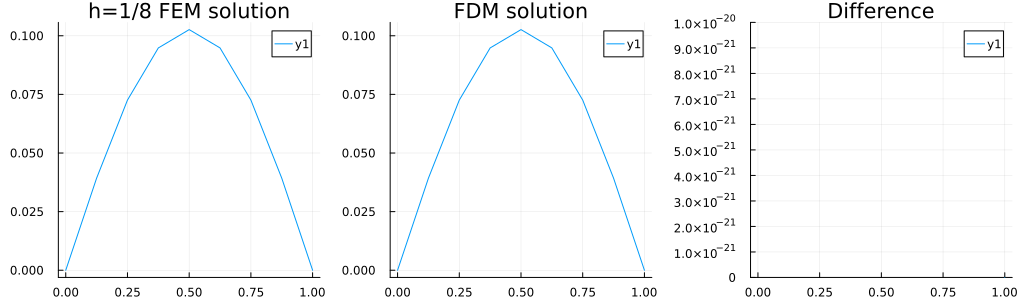

In [212]:
h=1/8; xs=range(0,1,step=h); p_e=get_p_e(xs)
A_fem=get_global_A_matrix(p_e); f_fem=get_global_f_matrix(p_e); u_fem=A_fem\f_fem
A_fdm=get_A_FDM(h); f_fdm=get_f_FDM(h); u_fdm=A_fdm\f_fdm
p1 = Plots.plot(xs, u_fem, title="h=1/8 FEM solution")
p2 = Plots.plot(xs, u_fdm, title="FDM solution")
p3 = Plots.plot(xs, u_fem - u_fdm, title="Difference", ylims=(0, 1e-20),
    yticks=0:1e-21:1e-20)
Plots.plot(p1, p2, p3, layout=(1,3), size=(1024,300))

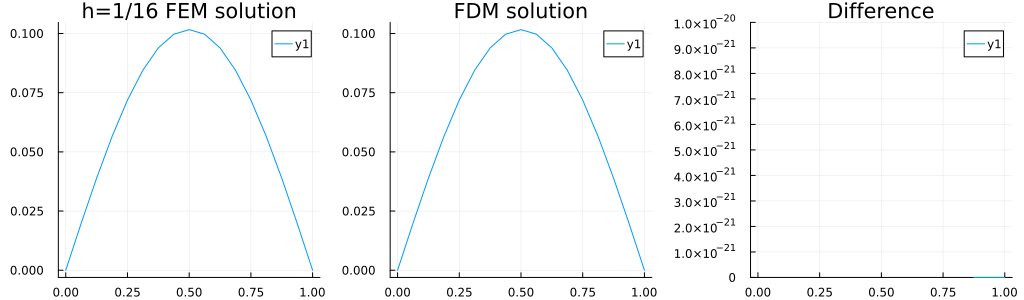

In [213]:
h=1/16; xs=range(0,1,step=h); p_e=get_p_e(xs)
A_fem=get_global_A_matrix(p_e); f_fem=get_global_f_matrix(p_e); u_fem=A_fem\f_fem
A_fdm=get_A_FDM(h); f_fdm=get_f_FDM(h); u_fdm=A_fdm\f_fdm
p1 = Plots.plot(xs, u_fem, title="h=1/16 FEM solution")
p2 = Plots.plot(xs, u_fdm, title="FDM solution")
p3 = Plots.plot(xs, u_fem - u_fdm, title="Difference", ylims=(0, 1e-20),
    yticks=0:1e-21:1e-20)
Plots.plot(p1, p2, p3, layout=(1,3), size=(1024,300))

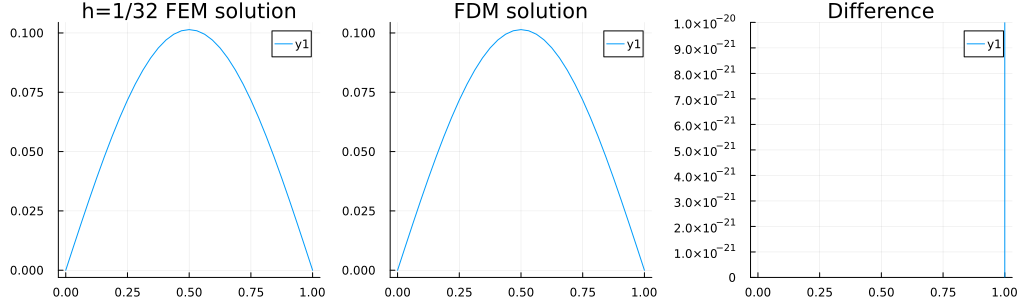

In [214]:
h=1/32; xs=range(0,1,step=h); p_e=get_p_e(xs)
A_fem=get_global_A_matrix(p_e); f_fem=get_global_f_matrix(p_e); u_fem=A_fem\f_fem
A_fdm=get_A_FDM(h); f_fdm=get_f_FDM(h); u_fdm=A_fdm\f_fdm
p1 = Plots.plot(xs, u_fem, title="h=1/32 FEM solution")
p2 = Plots.plot(xs, u_fdm, title="FDM solution")
p3 = Plots.plot(xs, u_fem - u_fdm, title="Difference", ylims=(0, 1e-20),
    yticks=0:1e-21:1e-20)
Plots.plot(p1, p2, p3, layout=(1,3), size=(1024,300))

We can see that in each plot, the difference "magically" is zero. This makes sense, as the $A$ and $f$ we used to find $u$ are identical, down to a scalar multiple (which cancels out!) and the initial conditions (which could be any number, so long as the row is all zeros except 1, and the $f$ contains a 0 at the corresponding entry. So they also "cancel out" in a sense). So the difference being nil is sensical to me. 

# Assignment 6: Extend the implementation to second-order quadratic basis functions.


### 6.1: First the implementation of a quadratic solver

There is a lot to explain about what happens here. In short (so that I can expand this text myself later):
- We have constructed $A_{e_i}$ in the past by constructing $$\int_{x_i}^{x_{i+1}}\phi_\alpha(x)'\cdot\phi_\beta(x)'dx$$ where $\phi(x)$ is a linear basis function. 
- We want to change this linear basis to be quadratic.
- Now our functions $\phi$ are defined to be second-order quadratic. We can do a coordinate transformation from $x\in[x_i,x_{i+1}]$ to $\xi\in[0,1]$, and integrate the resulting functions $$\phi_i(\xi)=2(\xi-1)(\xi-\frac{1}{2})\newline\phi_{i+\frac{1}{2}}(\xi)=4\xi(1-\xi)\newline\phi_{i+1}(\xi)=2\xi(\xi-0.5)$$ inside of the integral, with $\alpha, \beta \in \{1,\frac{3}{2},2\}$.
- Doing this, we find the elements of a new matrix $A_{e_i}$, now 3x3, which represents the stiffness matrix. We can construct the "real" matrix $A$ in a similar way as before. The elements of $A_{e_i}$ become, as a result of integration:

$$
A_{e_i} =
\begin{bmatrix}
\cfrac{7}{3h} & \cfrac{-8}{3h} & \cfrac{1}{3h} \\
\cfrac{-8}{3h} & \cfrac{16}{3h} & \cfrac{-8}{3h} \\
\cfrac{1}{3h} & \cfrac{-8}{3h} & \cfrac{7}{3h}
\end{bmatrix}
$$

In a similar fashion $f_{e_i}$ is constructed by three elements, which I will name $F_{e_i}^\alpha$ for $\alpha\in\{1,\frac{3}{2}, 2\}$. For these, we compute
$$F_{e_i}^\alpha=\int_{x_i}^{x_{i+1}}f(x)\phi_\alpha(x)dx\newline=\cfrac{x_{i+1}-x_{i}}{6}[f(x_i)\phi_\alpha(x_i)+4f(x_{i+\frac{1}{2}})\phi_\alpha(x_{i+\frac{1}{2}})+f(x_{i+1})\phi_\alpha(x_{i+1})]$$
meaning that the vector $f_{e_i}$ is constructed as follows (by noting $\phi_\alpha(x_i)$ is 1 only when $i$ in $x_i$ equals $\alpha-1$, otherwise zero)
$$
f_{e_i}=\begin{bmatrix}F_{e_i}^1\\ F_{e_i}^{1.5}\\ F_{e_i}^2\end{bmatrix}=\cfrac{1}{6h}\begin{bmatrix}f(x_i)\\ 4f(x_{i+\frac{1}{2}})\\ f(x_{i+1})\end{bmatrix},\quad\begin{matrix}\alpha=1\\ \alpha=\frac{3}{2}\\ \alpha=2\end{matrix}
$$

We now have enough info to construct $A$ and $f$ again, to make $u$. 

Before we start making the new functions, I should mention I've decided to change how p_e is built up. Changing to the 3x3 basis requires the intermediate elements, and their representation in p_e is nontrivial. I've decided to do it as follows:
$p$ is the matrix that contains locations, in sets which are logically related. 
- When using linear basis functions, those sets always contained two numbers: the two endpoints of an interval
- After switching to quadratic functions, those sets now need to consist of three elements, of which two mark the ends of an interval
- We can not, as before, do a "sliding window" approach. If we were to do this, then two consecutive sets might look like:

<code>(x[1], x[3/2], x[2])</code> (sensical set containing the midpoints between the grid definition)
       
<code>(x[3/2], x[2], x[5/2])</code> (nonsensical! x[3/2] and x[5/2] are not defined grid points, they are inserted **after** mesh construction)

- We need the elements of $p$ to still only be those sets which contain two endspoint and all the midpoints between them:

<code>(x[1], x[3/2], x[2])</code> (Two grid points make the endpoints, midpoints are inserted for simulation precision)

<code>(x[2], x[5/2], x[3])</code> (Same as above. No windows starting and ending on midpoints.)

- To make $e$ be sensical as well, its entries are changed in a similar method, so that its ordering doesn't go (1,2,3), (2,3,4), (3,4,5) but rather (1,2,3),(3,4,5),(5,6,7), thus skipping the midpoints.

The variable ndofs will come to mean "#N of degrees of freedom", which is the amount of simulation nodes including gridpoints. The number N is then the amount of true gridpoints. It is sometimes important to use one or the other, otherwise the size of loops doesn't make sense.

In [215]:
function get_p_e_quad(xs)
    # Using a list of x, construct p matrix
    # We could do this from h directly, but only for uniformly distributed x's
    
    N=length(xs)-1 #num. of elements
    ndofs=2*N+1 # num. of degrees of freedom i.e. independent values.

    # p now just contains the elements. e describes connectivity.
    p=zeros(ndofs)
    for i in 1:N
        p[2*i - 1] = xs[i]                         # left node
        p[2*i]     = (xs[i] + xs[i+1]) / 2         # midpoint
    end
    p[end] = xs[end]  # last node
    
    e=zeros(Int64, N, 3)


    for i in 1:N
        e[i, 1] = 2*i-1
        e[i, 2] = 2*i
        e[i, 3] = 2*i+1
    end

    return p, e
end

function f_source(x)
    f((x)) = sin(3.1415 * x);

    return f(x)
end

function get_A_matrix_quad(p_e, i)
    # Returns the "template" A_e_i
    
    p, e  = p_e #unpack
    
    A=[7/3 -8/3 1/3; -8/3 16/3 -8/3; 1/3 -8/3 7/3]
    
    x_i0=p[e[i, :][1]] # The nodes at the location defined by e.
    x_i2=p[e[i, :][3]]
    h = x_i2-x_i0 

    if h==0 
        error("Division by zero in get_A_matrix")
    end
    
    frac = 1 / h
    return frac*A
end

function get_f_matrix_quad(p_e, i)
    p, e = p_e

    x_i0=p[e[i,:][1]]
    x_i1=p[e[i,:][2]]
    x_i2=p[e[i,:][3]]
    h = x_i2-x_i0

    frac = h/6
    f = [f_source(x_i0), 4*f_source(x_i1),f_source(x_i2)]
    return frac*f
end

function get_global_A_matrix_quad(p_e)
    # Todo: Adapt this function to use quadratics
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e, 1)

    # The matrix A needs to be able to include the midpoints in the mesh.
    # A makes use of e, so e needs to be reshaped to incorporate this change.

    # n describes number of intervals!! This needs to not account for midpoints!
    A = zeros(ndofs, ndofs)

    for i in 1:num_elements
        A_e_i=get_A_matrix_quad(p_e, i)

        for j in 1:3
            for k in 1:3
                A[e[i,j],e[i,k]] += A_e_i[j,k]
            end
        end
    end

    # Boundary conditions...
    A[1,:].=0
    A[1,1]=1
    
    
    A[end,:].=0
    A[end,end]=1

    return A
end

function get_global_f_matrix_quad(p_e)
    # TODO: Adapt this function to use quadratics.
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e,1)
    
    f = zeros(ndofs, 1)

    for i in 1:num_elements
        f_e_i=get_f_matrix_quad(p_e, i)

        for j in 1:3
            f[e[i,j]]+=f_e_i[j]
        end
    end
    
    # BC's
    f[1]=0
    f[end]=0
    return f
end
;

Wow! What a bunch of code. Let's demonstrate that the function works as expected. Let's do a test with h=1/3 (or n=3) to see if the new solver makes sense.

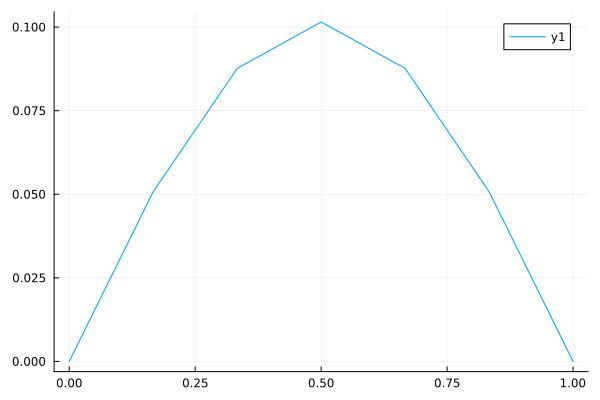

In [216]:
n=3
xs = range(0, 1, length=n+1)
p_e = get_p_e_quad(xs)
A=get_global_A_matrix_quad(p_e)
f=get_global_f_matrix_quad(p_e)

u=A\f
xs_quad=range(0,1,2*n+1)
Plots.plot(xs_quad, u)

We can see 7 degrees of freedom, which spring from our h=1/3. There are 1/h+1=4 intervals, but each interval is given a midpoint, thus yielding 7 points on which $u$ is defined. Luckily, the shape of the solution looks similar to that of FDM or FEM without midpoints.

### Assignment 6.2: Now we compare the performance of one solver against the other.

We define the two functions for the error taking an argument of 'h' and returning the maximal error. One function does 1st order diff., one does 2nd order diff. Then we make a log-log plot showing the error as a function of h, in both cases. It is important to note that we adjust the input size such that quadratic FEM has the same number of points on which u is defined as linear FEM. So their input h is slightly different.

In [217]:
function u_exact(x)
    return 1/(pi^2)*sin(pi*x)
end

function error_linear(h)
    N=convert(Int64, 1/h+1)
    # We need the approximate solution produced by the solver, as well as the solution found by solving the Poisson eq. by hand.
    xs = range(0, 1, length=N)
    
    real_solution=u_exact.(xs)

    p_e=get_p_e(xs)
    A=get_global_A_matrix(p_e)
    f=get_global_f_matrix(p_e)

    approximate_solution=A\f
    return error=maximum(abs.(real_solution-approximate_solution))
end

function error_quad(h)
    # We need to compensate h here with a mul. of 2, so that the resolution of the grid is the same. That is, the size of the matrices involved are of equal size. 
    # If you have 4x the memory and computational time, it makes sense to have a better approx.
    N=convert(Int64, 1/(2h)+1)
    xs = range(0, 1, length=2*N-1)
    real_solution=u_exact.(xs)

    xs = range(0, 1, length=N)
    p_e=get_p_e_quad(xs)
    A=get_global_A_matrix_quad(p_e)
    f=get_global_f_matrix_quad(p_e)

    approximate_solution=A\f
    return error=maximum(abs.(real_solution-approximate_solution))
end
;

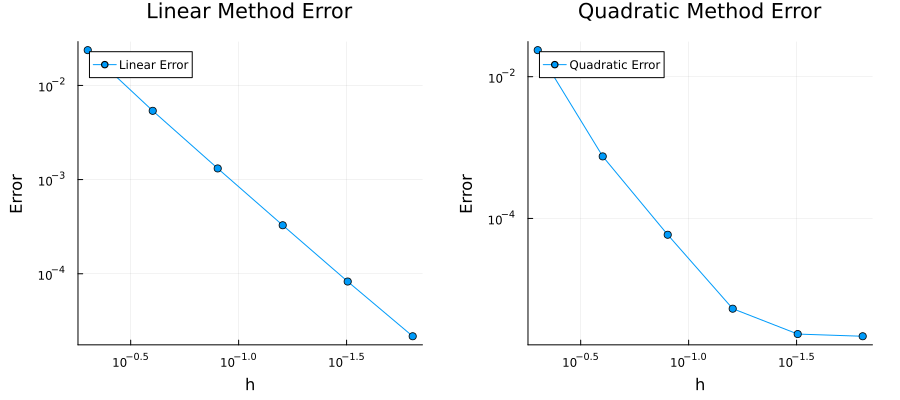

In [218]:
using Plots

# Step sizes
hs = [1/2, 1/4, 1/8, 1/16, 1/32, 1/64]

# Initialize error arrays
errors_lin = Float64[]
errors_quad = Float64[]

# Compute errors
for h in hs
    append!(errors_lin, error_linear(h))
    append!(errors_quad, error_quad(h))
end

# Linear error plot (subplot 1)
p1 = Plots.plot(
    hs,
    errors_lin,
    xscale = :log10,
    yscale = :log10,
    xflip = true,               # smaller h on the right
    marker = :circle,
    label = "Linear Error",
    xlabel = "h",
    ylabel = "Error",
    title = "Linear Method Error",
    margin = 5mm
)

# Quadratic error plot (subplot 2)
p2 = Plots.plot(
    hs,
    errors_quad,
    xscale = :log10,
    yscale = :log10,
    xflip = true,               # smaller h on the right
    marker = :circle,
    label = "Quadratic Error",
    xlabel = "h",
    ylabel = "Error",
    title = "Quadratic Method Error",
    margin = 5mm
)

# Combine side-by-side
Plots.plot(p1, p2, layout = (1, 2), size = (900, 400))

### Find the slope of these lines.
I'm having trouble determining why the quadratic method isn't a straight line... I think something subtle is wrong with my quadratic method, but I can't see a fault in the solutions it produced. Maybe the error is just meant to be like this? I'll do the best I can with the data that is available to me.

Slope (linear FEM)   = 2.015122893573294
Slope (quadratic FEM)= 2.7286645685723796


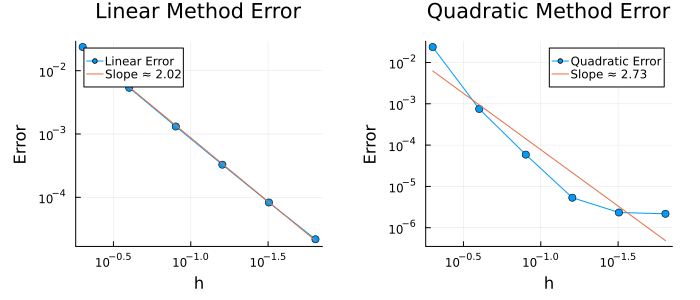

In [219]:
using Statistics

# Convert to logs
logh = log10.(hs)
logerr_lin = log10.(errors_lin)
logerr_quad = log10.(errors_quad)

# Fit slope (least squares)
slope_lin = cov(logh, logerr_lin) / var(logh)
slope_quad = cov(logh, logerr_quad) / var(logh)

println("Slope (linear FEM)   = ", slope_lin)
println("Slope (quadratic FEM)= ", slope_quad)

fit_lin = slope_lin .* logh .+ (mean(logerr_lin) - slope_lin * mean(logh))
fit_quad = slope_quad .* logh .+ (mean(logerr_quad) - slope_quad * mean(logh))

# Add to plots
p3 = Plots.plot!(p1, hs, 10 .^ fit_lin, label="Slope ≈ $(round(slope_lin, digits=2))")
p4 = Plots.plot!(p2, hs, 10 .^ fit_quad, label="Slope ≈ $(round(slope_quad, digits=2))")
Plots.plot(p3, p4, layout=(1,2), size=(700, 300))

# Assignment 7, option 2

# I will append my work as an image at the end!

### Assignment 7.2.1: Plot the exact solutions $u^e(x)$

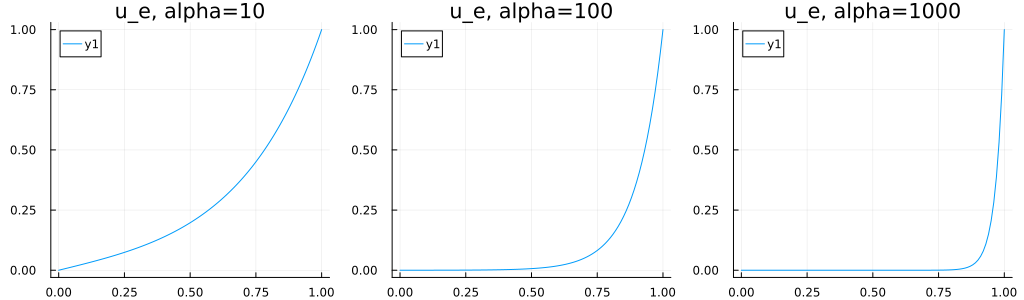

In [220]:
h=0.01
xs=0:0.01:1
u_exact(a, x) = sinh(sqrt(a)*x)/sinh(sqrt(a))

p1 = Plots.plot(xs, u_exact.(10, xs), title="u_e, alpha=10")
p2 = Plots.plot(xs, u_exact.(100, xs), title="u_e, alpha=100")
p3 = Plots.plot(xs, u_exact.(1000, xs), title="u_e, alpha=1000")

Plots.plot(p1, p2, p3, layout=(1,3), size=(1024, 300))

$\alpha$ mimics the strength of the eddy-current damping, which would physically correspond to $\mu\sigma\omega$. We can see that when $\alpha$ gets larger, more of the change in u is concentrated around x=1.

### Assignment 7.2.2
Give for both 1st and 2nd order elts the expression for element matrix $A_{e_i}$. We're going to use a nice trick, namely that we have already solved for the $\frac{d^2}{dx^2}$ operator:

$$\frac{d^2u}{dx^2}+\alpha u=0 \newline \Rightarrow(\frac{d^2}{dx^2}+\alpha)u=0$$

Using the reasoning as we have to acquire the definition of the $\frac{d^2}{dx^2}$ operator, we can also find the one representing $\alpha u$. When we multiply by a test function $\phi$, the first one yielded a double derivative and two first-order derivatives after integration by parts. Because $\alpha$ is a 0-th order operator, the entries to the "stamp" this contributes thus is 

$$\int_{x_i}^{x_{i+1}}\phi_\alpha(x)\cdot\phi_\beta(x)dx$$

for the choice of our basis functions.

In the linear case ($\phi_1(x)=x,\phi_2(x)=-x+1$)this becomes

$$\frac{h}{6}\begin{bmatrix}2&1\\1&2\end{bmatrix}$$

When using the quadratic functions (see above) we acquire

$$\frac{h}{30}\begin{bmatrix}4&2&-1\\2&16&2\\-1&2&4\end{bmatrix}$$

To implement these, we slightly have to adapt the matrix construction to not only template $A_{e_i}$, but also the matrices we define here. Syntactically, very little changes. Additionally, as $f$ is zero everywhere, we can ignore its "special" construction and only set its BC to 1 at the right boundary.

In [221]:
function get_A_matrix_eddy(p_e, i, alpha)
    p = p_e[1]
    
    A=Tridiagonal([-1.], [1.,1.],[-1.])
    x_i0=p[i,1]
    x_i1=p[i,2]
    h = x_i1-x_i0

    if h==0 
        error("Division by zero in get_A_matrix")
    end
    
    frac_A = 1 / h

    # The linear part
    B=Tridiagonal([1.],[2.,2.], [1.])
    frac_B = h / 6

    return frac_A*A + alpha * frac_B * B
end

function get_global_A_matrix_eddy(p_e, alpha)
    e = p_e[2]

    # n describes number of intervals!!
    n = length(e[:,1])
    A=zeros(n+1, n+1)

    for i in 1:n
        A_e_i=get_A_matrix_eddy(p_e, i, alpha)

        for j in 1:2

            for k in 1:2
                A[e[i,j],e[i,k]]=A[e[i,j],e[i,k]]+A_e_i[j,k]
            end
        end
    end

    # Boundary conditions...
    A[1,1]=1
    A[1,2]=0

    A[end,:].=0
    A[end,end]=1

    return A
end

function get_A_matrix_eddy_quad(p_e, i, alpha)
    # Returns the "template" A_e_i
    
    p, e  = p_e #unpack
    
    A=[7/3 -8/3 1/3; -8/3 16/3 -8/3; 1/3 -8/3 7/3]
    
    x_i0=p[e[i, :][1]] # The nodes at the location defined by e.
    x_i2=p[e[i, :][3]]
    h = x_i2-x_i0 

    if h==0 
        error("Division by zero in get_A_matrix")
    end

    # The linear part
    B=[4 2 -1;2 16 2;-1 2 4]
    frac_B = h / 30
    
    frac_A = 1 / h
    return frac_A * A + alpha * frac_B * B
end

function get_global_A_matrix_eddy_quad(p_e, alpha)
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e, 1)

    # The matrix A needs to be able to include the midpoints in the mesh.
    # A makes use of e, so e needs to be reshaped to incorporate this change.

    # n describes number of intervals!! This needs to not account for midpoints!
    A = zeros(ndofs, ndofs)

    for i in 1:num_elements
        A_e_i=get_A_matrix_eddy_quad(p_e, i, alpha)

        for j in 1:3
            for k in 1:3
                A[e[i,j],e[i,k]] += A_e_i[j,k]
            end
        end
    end

    # Boundary conditions...
    A[1,:].=0
    A[1,1]=1
    
    A[end,:].=0
    A[end,end]=1

    return A
end

function get_global_f_matrix_eddy_quad(p_e)
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e,1)
    
    # No initial values; its just zero
    f = zeros(ndofs, 1)

    # BC's
    f[1]=0
    f[end]=1
    return f
end

function get_global_f_matrix_eddy(p_e)
    e = p_e[2]

    n = length(e[:,1])
    f = zeros(n+1, 1)

    # BC's
    f[1]=0
    f[end]=1

    return f
end
;

### Assignment 7.2.3 and 7.2.4: Solve the problem for three values of $\alpha$ above. Plot log10 of difference between FEM and analytical solution.

In [222]:
# Definitions for simulation


# Linear parts
N=100; xs=range(0, 1, N+1)
p_e=get_p_e(xs);

alpha=10; 
A=get_global_A_matrix_eddy(p_e, alpha)
f=get_global_f_matrix_eddy(p_e)
u_lin_10=A\f
u_exact(x)=sinh(sqrt(alpha)*x)/sinh(sqrt(alpha))
u_exact_10=u_exact.(xs)

alpha=100;
A=get_global_A_matrix_eddy(p_e, alpha)
f=get_global_f_matrix_eddy(p_e)
u_lin_100=A\f
u_exact(x)=sinh(sqrt(alpha)*x)/sinh(sqrt(alpha))
u_exact_100=u_exact.(xs)

alpha=1000;
A=get_global_A_matrix_eddy(p_e, alpha)
f=get_global_f_matrix_eddy(p_e)
u_lin_1000=A\f
u_exact(x)=sinh(sqrt(alpha)*x)/sinh(sqrt(alpha))
u_exact_1000=u_exact.(xs)


# The quadratic parts
# N needs to be different again, because of reasons we discussed.
N=50; xs=range(0, 1, N+1)
p_e=get_p_e_quad(xs);

alpha=10; 
A=get_global_A_matrix_eddy_quad(p_e, alpha)
f=get_global_f_matrix_eddy_quad(p_e)
u_quad_10=A\f

alpha=100;
A=get_global_A_matrix_eddy_quad(p_e, alpha)
f=get_global_f_matrix_eddy_quad(p_e)
u_quad_100=A\f

alpha=1000;
A=get_global_A_matrix_eddy_quad(p_e, alpha)
f=get_global_f_matrix_eddy_quad(p_e)
u_quad_1000=A\f

;

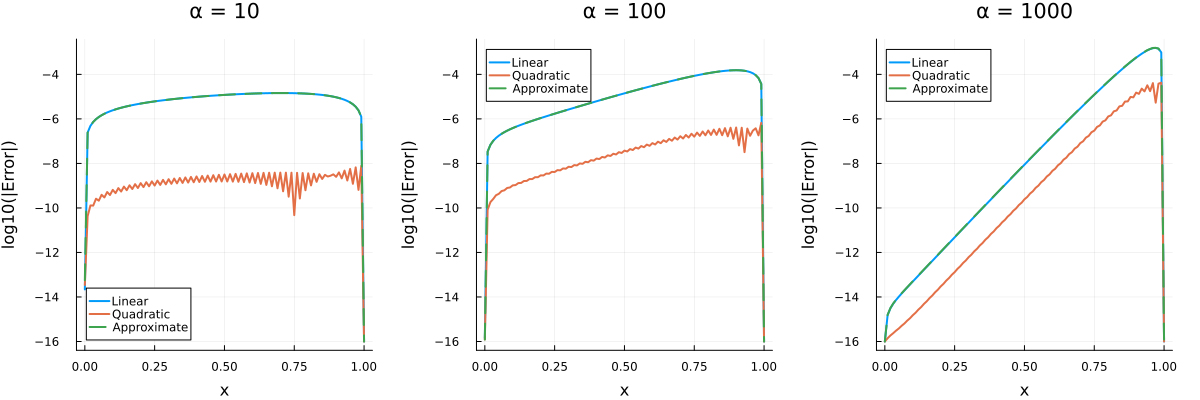

In [223]:
N=100; xs=range(0, 1, N+1)


# 1. Prepare the Error data (Linear)
# We add a tiny epsilon (1e-16) to avoid log10(0) at the boundaries
err_lin_10   = log10.(abs.(u_lin_10 - u_exact_10) .+ 1e-16)
err_lin_100  = log10.(abs.(u_lin_100 - u_exact_100) .+ 1e-16)
err_lin_1000 = log10.(abs.(u_lin_1000 - u_exact_1000) .+ 1e-16)

# 2. Prepare the Error data (Quadratic) 
# Note: Ensure u_quad_... variables exist and match the size of xs_quad
err_quad_10   = log10.(abs.(u_quad_10 - u_exact_10) .+ 1e-16)
err_quad_100  = log10.(abs.(u_quad_100 - u_exact_100) .+ 1e-16)
err_quad_1000 = log10.(abs.(u_quad_1000 - u_exact_1000) .+ 1e-16)

# 3. Error between analytical approximations
err_aprx_10   = log10.(abs.(u_lin_10 - u_quad_10) .+ 1e-16)
err_aprx_100  = log10.(abs.(u_lin_100 - u_quad_100) .+ 1e-16)
err_aprx_1000 = log10.(abs.(u_lin_1000 - u_quad_1000) .+ 1e-16)

# 3. Create individual subplots
p1 = Plots.plot(xs, err_lin_10, label="Linear", title="α = 10", lw=2)
Plots.plot!(p1, xs, err_quad_10, label="Quadratic", lw=2)
Plots.plot!(p1, xs, err_aprx_10, label="Approximate", lw=2, ls=:dash)

p2 = Plots.plot(xs, err_lin_100, label="Linear", title="α = 100", lw=2)
Plots.plot!(p2, xs, err_quad_100, label="Quadratic", lw=2)
Plots.plot!(p2, xs, err_aprx_100, label="Approximate", lw=2, ls=:dash)

p3 = Plots.plot(xs, err_lin_1000, label="Linear", title="α = 1000", lw=2)
Plots.plot!(p3, xs, err_quad_1000, label="Quadratic", lw=2)
Plots.plot!(p3, xs, err_aprx_1000, label="Approximate", lw=2, ls=:dash)

# 4. Combine into a side-by-side layout
Plots.plot(p1, p2, p3, 
    layout = (1, 3), 
    size = (1200, 400), 
    xlabel = "x", 
    ylabel = "log10(|Error|)",
    link = :y, # Keeps the Y-axis scale consistent for comparison
    margin = 5Plots.mm
)

In the above figure we have a lot to discuss.
### 7.2.3:
Focussing on the Blue and Orange lines, we can see the Linear approximation does worse than the quadratic approximation. In each case, we can see that the solutions exactly agree at the Dirichlet boundary conditions. (Where we set a "lower boundary" to our error of e-16, to avoid log(0)). We can also see that the error in hte quadratic approximation is less stable than that of the linear approximation, but that its performance is still better everyhwere.

### 7.2.4
Now turning our attention to the dashed green line, we can see it overlaps almost perfectly with the blue line. Visually its resemblance is perfect. This makes sense, as the difference of the quadratic approximation to the real solution is so many orders of magnitude smaller than the linear solution. The difference between linear and quadratic approx's would be very similar to the difference between the linear and real approx., as the quadratic and real are so close to one another. This is why it sits "on top of" the blue line which represents the linear approx.

# Assignment 8.4
I've chosen to do assignment 8.4, as it is a relatively straightforward change in Julia, which supports complex numbers by design. We change the matrices to contain Complex numbers, and Julia will handle most of the other changes. We can use the real() and imag() functions to extract real and imaginary parts. It's not explicitly given, but I will assume $f=50Hz$ and $\alpha=100$, as I am a power engineering student B). This automatically implies $|\sigma|=|\frac{\alpha}{\omega}|=\frac{100}{2\pi\cdot50}=\frac{1}{\pi}$

In [224]:
function get_A_matrix_imaginary(p_e, i, jow)
    # Returns the "template" A_e_i
    
    p, e  = p_e #unpack
    
    A=[7/3 -8/3 1/3; -8/3 16/3 -8/3; 1/3 -8/3 7/3]
    
    x_i0=p[e[i, :][1]] # The nodes at the location defined by e.
    x_i2=p[e[i, :][3]]
    h = x_i2-x_i0 

    if h==0 
        error("Division by zero in get_A_matrix")
    end

    # The linear part
    B=[4 2 -1;2 16 2;-1 2 4]
    frac_B = h / 30
    
    frac_A = 1 / h
    return frac_A * A + jow * frac_B * B
end

function get_global_A_matrix_imaginary(p_e, jow)
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e, 1)

    # The matrix A needs to be able to include the midpoints in the mesh.
    # A makes use of e, so e needs to be reshaped to incorporate this change.

    # n describes number of intervals!! This needs to not account for midpoints!
    A = zeros(ComplexF64, ndofs, ndofs)

    for i in 1:num_elements
        A_e_i=get_A_matrix_imaginary(p_e, i, jow)

        for j in 1:3
            for k in 1:3
                A[e[i,j],e[i,k]] += A_e_i[j,k]
            end
        end
    end

    # Boundary conditions...
    A[1,:].=0
    A[1,1]=1+0im
    
    A[end,:].=0
    A[end,end]=1+0im

    return A
end

function get_global_f_matrix_imaginary(p_e)
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e,1)
    
    # No initial values; its just zero
    f = zeros(ComplexF64, ndofs, 1)

    # BC's
    f[1]=0+0im
    f[end]=1+0im
    return f
end
;

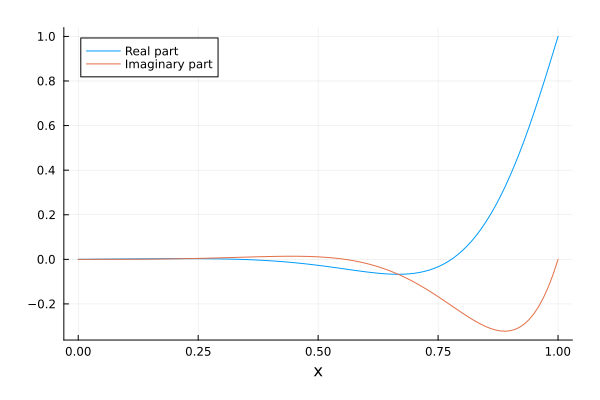

In [225]:
o=1/pi # Sigma. o looks like sigma.
w = 2*pi*50
N=50; xs=range(0,1,N+1); p_e=get_p_e_quad(xs)

A = get_global_A_matrix_imaginary(p_e, im*o*w)
f = get_global_f_matrix_imaginary(p_e)

xs=range(0,1,2*N+1)
u=A\f

p1 = Plots.plot(xs, real(u), xlabel="x", margin=5mm, label="Real part")
Plots.plot!(p1, xs, imag(u), label="Imaginary part")

# Assignment 9.3
I've chosen part 3 of this assignment, as I think it is the least work. As the RHS here is nil, I haven't used a map, but it's not hard to see how it would be done in, for example, the first quadratic solver. Simply map i -> get_F_matrix for each i, and then do the foreach process "normally" to assemble f. I'm demonstrating using the imaginary solver:

In [226]:
function get_global_A_matrix_imaginary_new(p_e, jow)
    p, e = p_e
    ndofs = length(p)
    num_elements = size(e, 1)

    A = zeros(ComplexF64, ndofs, ndofs)

    # Map: compute all element matrices
    element_matrices = map(i -> get_A_matrix_imaginary(p_e, i, jow), 1:num_elements)

    # Assemble
    foreach(1:num_elements) do i
        A_e = element_matrices[i]
        nodes = e[i, :]

        for j in 1:3
            for k in 1:3
                A[nodes[j], nodes[k]] += A_e[j,k]
            end
        end
    end

    # Boundary conditions
    A[1,:] .= 0
    A[1,1] = 1 + 0im

    A[end,:] .= 0
    A[end,end] = 1 + 0im

    return A
end
;

### We can now compare the solutions of the newly organised solver to the old version. We expect the difference to be zero.

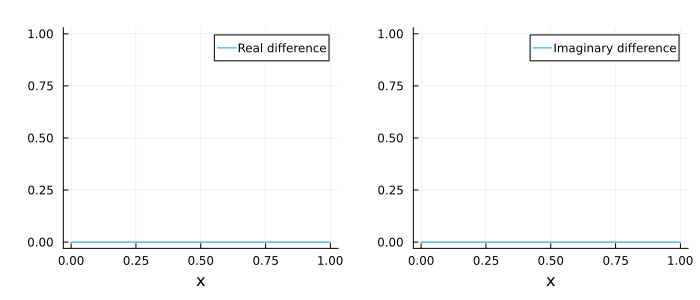

In [227]:
o=1/pi # Sigma. o looks like sigma.
w = 2*pi*50
N=50; xs=range(0,1,N+1); p_e=get_p_e_quad(xs)

A_new = get_global_A_matrix_imaginary_new(p_e, im*o*w)
f_new = get_global_f_matrix_imaginary(p_e)

xs=range(0,1,2*N+1)
u_new=A_new\f_new

p1 = Plots.plot(xs, real(u)-real(u_new), xlabel="x", margin=5mm, label="Real difference")
p2 = Plots.plot(xs, imag(u)-imag(u_new), xlabel="x", label="Imaginary difference")
Plots.plot(p1,p2, layout=(1,2), size=(700,300))

It's zero! As we expected, as we haven't made any functional changes. So we have succesfully used a map to construct the matrix A!

# Assignment 10: Feedback and Github

I'd like to give feedback not on the proposed points, but on the exercise sheet itself (if that is welcome, I hope)
- As I have mentioned during the classes, the boundary conditions that this sheet expects students to use were not always entirely clear. To reiterate what I mean: 
  - On page 1 we get Hom. Dirichlet at x=0 and x=1
  - In pre-assignment 11 we are explained how to set the leftmost hom. Dirichlet BC, but the text then suggests that "homogeneous Neumann BC do not require separate treatment", suggesting the right boundary might be Neumann, but remaining unclear
  - During the lecture, I have been told to use two homogeneous Dirichlet boundaries, to be able to compare solutions, as a Neumann boundary would introduce differences near the right boundary.
  - Assignment 7-2 was very clear about the BC, which was neat
  - Assignment 8-4 seemed like an extension to 7-2, but changed the setup sufficiently for me to have appreciated it to re-specify the BC's (and IC's! What should $\sigma$ be?)
- Technically a small detail, but the notation in the fractions of $\phi$ in Assignment 6 is weird. The bottom sides of the fractions specify e.g. $(x_1-x_{\frac{3}{2}})\cdot(x_{\frac{3}{2}}-x_{2})$. From the logic, these are symbolically meant to represent an interval, but given minus signs to be... neater? I'm not sure. The first step I made in my derivation was to multiply the contents inside brackets with -1, as this permits an easier transition from $x$ to $\xi$. 
- One cool thing about FEM is that we can apply it to an arbitrary division of $[0,1]$ into intervals; the intervals don't need to be equally spaced anymore! I would have liked the exercise to make this point clear by featuring (for example) an exercise where you are asked to time simulations on a domain that is equally spaced, versus a domain that is finer near a simulation detail, and see if you can get a better time with the same amount of gridpoints. Maybe that is missing the point of the exercise sheets, though, and I already thought it was quite lengthy.
- I do want to mention that the steps taken towards getting the FEM "engine" to work were structured quite well. I wasn't initially happy about the existence of the pre-assignments ("Theres more questions on the back???"), but they did a very good job of making sure the handin-assignments themselves weren't an absolute mess. If the pre-assignments hadn't been there, and the first assignment on the sheet would have been Assignment 1 on page 4, I would have probably preferred unenrolling. So, well done! 

I'll place this sheet in the same GitHub directory as last time, https://github.com/Hephaestois/Hazels_FEM_EE4375.


